Scaler  
LabelEncoder  
Standard Scaler   
train_test_split  
Logistic Regression   
accuracy_score

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_excel(r"C:\Users\dell\Downloads\1775106859-Financial_Sample.xlsx")

In [4]:
df.shape

(700, 16)

In [5]:
df.isnull().sum()

Segment                 8
Country                11
Product                 8
Discount Band          62
Units Sold              5
Manufacturing Price     0
Sale Price              7
Gross Sales             5
Discounts               5
 Sales                  0
COGS                    0
Profit                  0
Date                    0
Month Number            0
Month Name              0
Year                    0
dtype: int64

In [6]:
df.select_dtypes(include="float").columns

Index(['Units Sold', 'Sale Price', 'Gross Sales', 'Discounts', ' Sales',
       'COGS', 'Profit'],
      dtype='object')

In [7]:
df.select_dtypes(include="object").columns

Index(['Segment', 'Country', 'Product', 'Discount Band', 'Month Name'], dtype='object')

In [8]:
print(df.columns.tolist())

['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold', 'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts', ' Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name', 'Year']


In [9]:
df.columns = df.columns.str.strip()

In [10]:
cols = ['Units Sold', 'Sale Price', 'Gross Sales', 'Discounts',
        'Sales', 'COGS', 'Profit']

df[cols] = df[cols].fillna(df[cols].mean())

#or
#cols = df.select_dtypes(include='number').columns
#df[cols] = df[cols].fillna(df[cols].mean())

In [11]:
for cols2 in ['Segment', 'Country', 'Product', 'Discount Band', 'Month Name']:
    df[cols2] = df[cols2].fillna(df[cols2].mode()[0])


    #Pandas 'mode()' ek series return karti hai kyunki ho sakta
    #  hai ek se zyada mode hon. '\[0\]' ka use karke hum series 
    # ki pehli value (jo sabse zyada baar aayi hai) nikalte hain 
    # taaki 'fillna' function use blanks mein fill kar sake.

In [12]:
df.isnull().sum()

Segment                0
Country                0
Product                0
Discount Band          0
Units Sold             0
Manufacturing Price    0
Sale Price             0
Gross Sales            0
Discounts              0
Sales                  0
COGS                   0
Profit                 0
Date                   0
Month Number           0
Month Name             0
Year                   0
dtype: int64

In [13]:
num_cols = list(df.select_dtypes(include="number").columns)

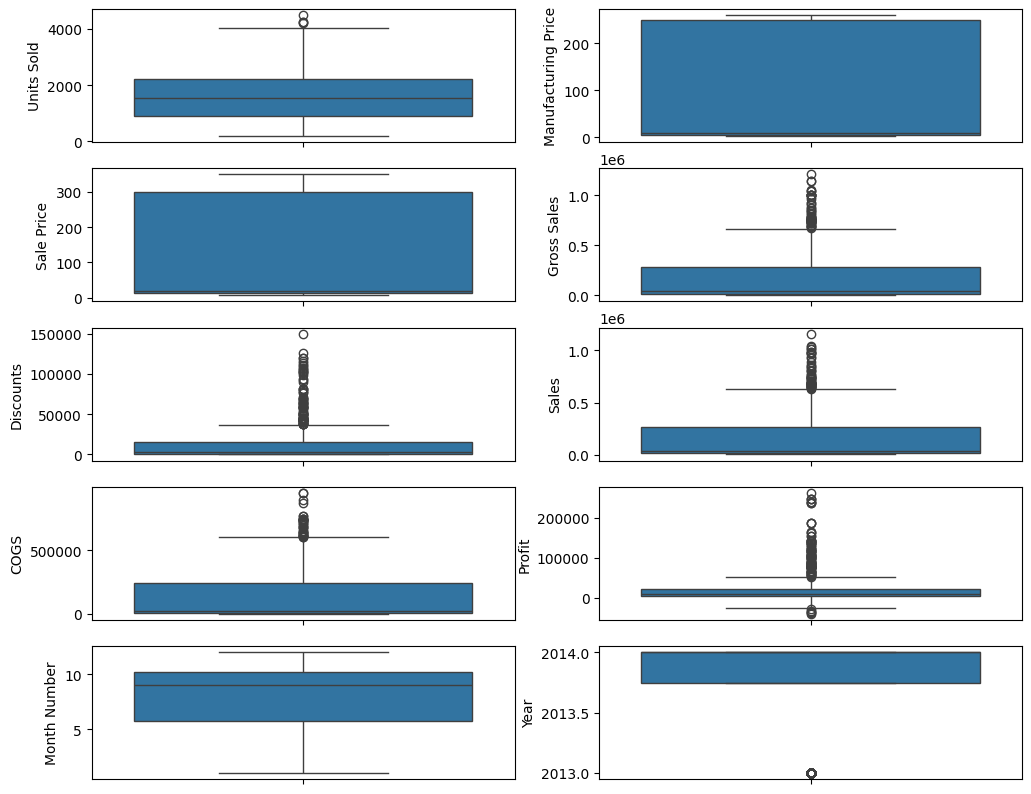

In [14]:
plt.figure(figsize=(12,10))
for cols in range(1,11):
    plt.subplot(5,2,cols)
    sns.boxplot(df[num_cols[cols-1]])
plt.show()

In [15]:
df["Sale Price"]

0       20.0
1       20.0
2       15.0
3       15.0
4       15.0
       ...  
695    300.0
696    300.0
697      7.0
698      7.0
699     12.0
Name: Sale Price, Length: 700, dtype: float64

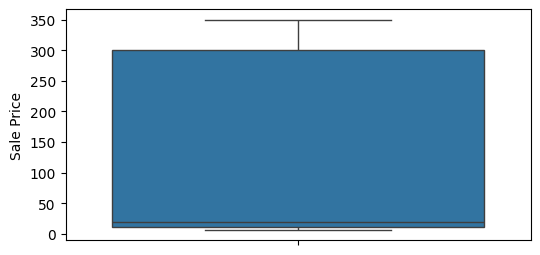

In [16]:
plt.figure(figsize=(6,3))
sns.boxplot(df['Sale Price'])
plt.show()

#Normalization : Normalization is also used to compressed the values between a given range [0-1],[0-100],[1,5] etc.

#Normalization is sensitive in case of outliers and sometimes with negative values  
#normalization Formula is => z = (x-min)/(max-min)


In [17]:
#Apply Normalization
df['Sale Price']=(df['Sale Price']-df['Sale Price'].min())/(df['Sale Price'].max()-df['Sale Price'].min())

In [18]:
df['Sale Price']

0      0.037901
1      0.037901
2      0.023324
3      0.023324
4      0.023324
         ...   
695    0.854227
696    0.854227
697    0.000000
698    0.000000
699    0.014577
Name: Sale Price, Length: 700, dtype: float64

In [19]:
df['Sale Price'].min(),df['Sale Price'].max()

(np.float64(0.0), np.float64(1.0))

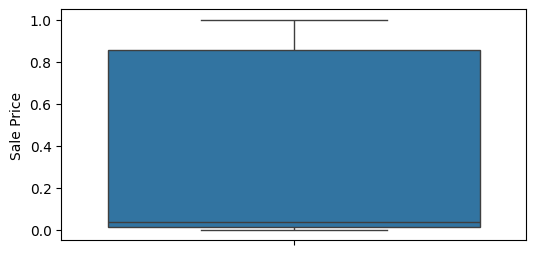

In [20]:
plt.figure(figsize=(6,3))
sns.boxplot(df['Sale Price'])
plt.show()

In [21]:
#df=pd.read_excel(r"C:\Users\dell\Downloads\1775106859-Financial_Sample.xlsx")

In [22]:
df['Sale Price']

0      0.037901
1      0.037901
2      0.023324
3      0.023324
4      0.023324
         ...   
695    0.854227
696    0.854227
697    0.000000
698    0.000000
699    0.014577
Name: Sale Price, Length: 700, dtype: float64

In [23]:
!pip install scikit-learn

In [24]:
from sklearn.preprocessing import MinMaxScaler


In [25]:
scaler = MinMaxScaler(feature_range=(0,1))

In [26]:
df['Sale Price'] = scaler.fit_transform(df[['Sale Price']])

In [27]:
df['Sale Price']

0      0.037901
1      0.037901
2      0.023324
3      0.023324
4      0.023324
         ...   
695    0.854227
696    0.854227
697    0.000000
698    0.000000
699    0.014577
Name: Sale Price, Length: 700, dtype: float64

In [42]:
df['Sale Price'].min(), df['Sale Price'].max()

KeyError: 'Sale Price'

In [28]:
#Load a dataset using sns
df = sns.load_dataset('titanic')

In [29]:
df.shape

(891, 15)

In [43]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [44]:
df = df.drop(columns=['deck'])

In [45]:
df = df.bfill()

In [46]:
df.isnull().sum().sum()

np.int64(0)

In [47]:
df.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False


In [48]:
df=df.drop(columns=['alive','alone','embarked','class','adult_male','who'])

In [49]:
df.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embark_town
0,0,3,male,22.0,1,0,7.2500,Southampton
1,1,1,female,38.0,1,0,71.2833,Cherbourg


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          891 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embark_town  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [51]:
#Apply Encoding
df.select_dtypes(include="object").columns

Index(['sex', 'embark_town'], dtype='object')

In [52]:
from sklearn.preprocessing import LabelEncoder

In [53]:
encoder =LabelEncoder()

In [56]:
for col in df.select_dtypes(include="object").columns:
    df[col] = encoder.fit_transform(df[col])

In [57]:
df.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embark_town
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0


In [58]:
len(df.columns)

8

In [59]:
num_cols = list(df.columns)

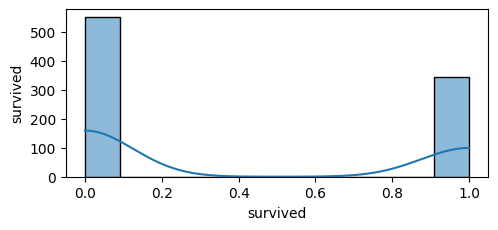

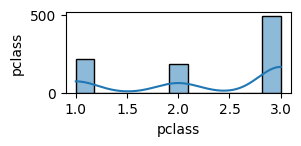

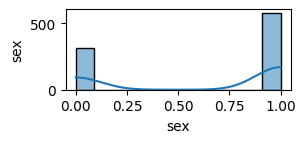

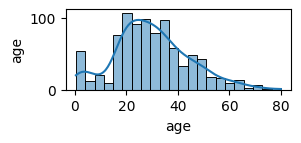

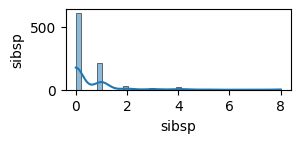

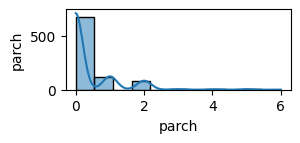

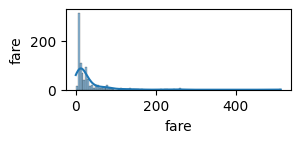

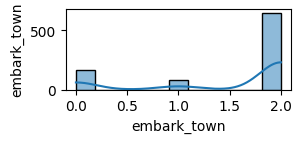

In [60]:
plt.figure(figsize=(12,10))
for i in range(1,9):
    plt.subplot(4,2,i)
    sns.histplot(df[num_cols[i-1]],kde=True)
    plt.ylabel(num_cols[i-1])
    plt.show()

In [61]:
from sklearn.preprocessing import StandardScaler

In [62]:
scaler = StandardScaler()

In [64]:
#Apply Scaling
for col in df.select_dtypes(include='float').columns:
    df[col]=scaler.fit_transform(df[[col]])

In [65]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embark_town
0,0,3,1,-0.539468,1,0,-0.502445,2
1,1,1,0,0.557213,1,0,0.786845,0
2,1,3,0,-0.265298,0,0,-0.488854,2
3,1,1,0,0.351585,1,0,0.420730,2
4,0,3,1,0.351585,0,0,-0.486337,2


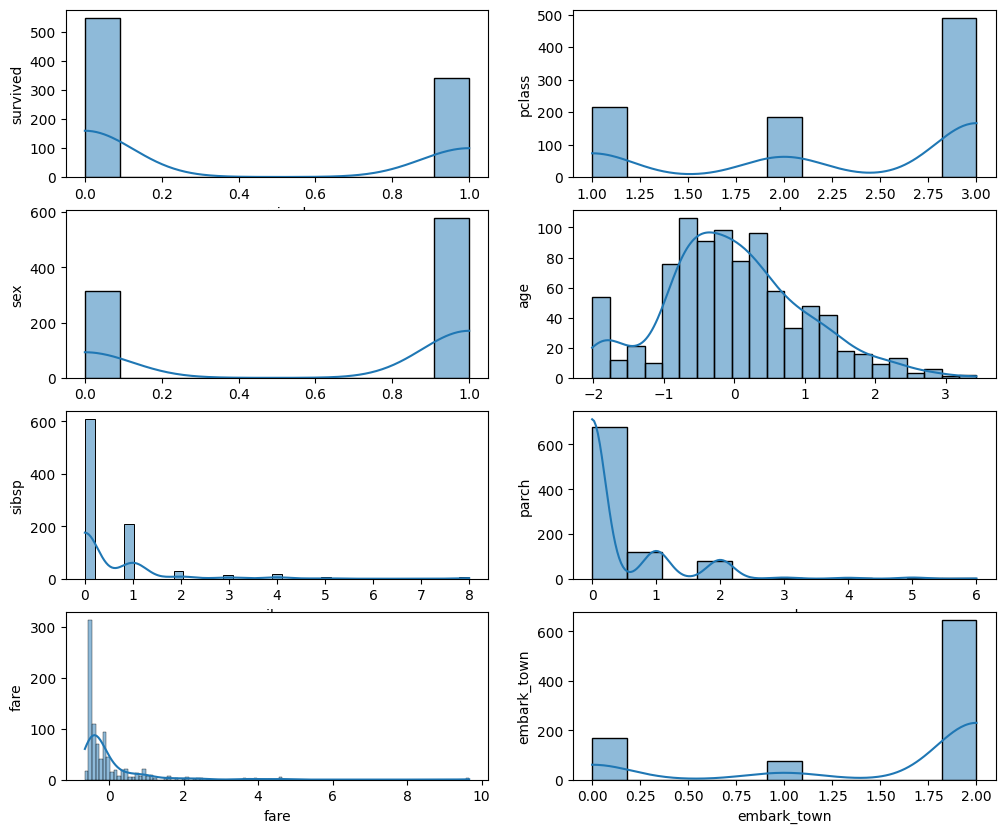

In [69]:
plt.figure(figsize=(12,10))
for i in range(1,9):
    plt.subplot(4,2,i)
    sns.histplot(df[num_cols[i-1]],kde=True)
    plt.ylabel(num_cols[i-1])
plt.show()

In [70]:
#Data Division
X= df.drop(columns=['survived'])
Y=df['survived']

In [75]:
#Train - Test Split
from sklearn.model_selection import train_test_split

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2
)

In [77]:
from sklearn.linear_model import LogisticRegression

In [78]:
model=LogisticRegression()

In [79]:
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

LogisticRegression()
In a Jupyter environment,please rerun this cell to show the HTML representation or trust the notebook.
On Github,the HTML representation is unable to render,please try loading this page with nbviewer.org.

In [80]:
y_pred = model.predict(X_test)

In [81]:
y_pred

array([1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1])

In [82]:
from sklearn.metrics import accuracy_score

In [83]:
accuracy_score(y_test,y_pred)*100

75.97765363128491

🧠 Overall Flow  
Simple language mein notebook ka kaam hai:  
Data → Clean → Prepare → Split → Model → Prediction → Accuracy  
Yaad rakhne ka shortcut:  
Load → Check → Clean → Convert → Split → Train → Predict → Evaluate  

PART 1 — Libraries Import  
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns  

pandas:
Data ko table format mein handle karne ke liye.

import pandas as pd

Hum ise usually pd naam se use karte hain.

numpy:
import numpy as np

Numbers aur mathematical operations ke liye.

matplotlib:
import matplotlib.pyplot as plt

Graphs banane ke liye.

seaborn:
import seaborn as sns

Beautiful/statistical graphs ke liye.

PART 2 — Excel File Load:-
df = pd.read_excel(
    r"C:\Users\dell\Downloads\1775106859-Financial_Sample.xlsx"
)
Simple meaning:
Excel file ko Python ke andar lekar aa rahe hain.

df = DataFrame

DataFrame ko tum Excel sheet jaisa samajh sakte ho.
Example:
Name	Age	Salary
Rahul	22	30000
Aman	25	40000
Ye Python mein df ho sakta hai.

PART 3 — Dataset ka Size:-
df.shape

Output:
(700, 16)

Meaning:
700 rows
16 columns

Simple:
Dataset mein 700 records aur 16 features/columns hain.

PART 4 — Missing Values Check:-
df.isnull().sum()

Ye check karta hai ki har column mein kitni empty/missing values hain.

Example:
Age       5
Salary    0
Country   2

Meaning:
Age mein 5 values missing
Salary mein kuch missing nahi
Country mein 2 missing

Notebook mein kuch columns mein missing values mili thi.

PART 5 — Numerical Columns Find
df.select_dtypes(include="float").columns

Ye sirf decimal/numerical columns identify karta hai.

Notebook mein:
Units Sold
Sale Price
Gross Sales
Discounts
Sales
COGS
Profit

mile.

Simple rule:
Numbers → numerical columns

PART 6 — Categorical Columns Find:-
df.select_dtypes(include="object").columns

Ye text/category wale columns find karta hai.

Notebook mein:
Segment
Country
Product
Discount Band
Month Name

mile.

Simple rule:
Text → categorical columns

PART 7 — Column Names Check
print(df.columns.tolist())

Isse dataset ke saare column names dikhenge.

Notebook mein ek column:
' Sales'
tha jisme beginning mein extra space tha.

PART 8 — Column Names Clean
df.columns = df.columns.str.strip()
strip() kya karta hai?

Extra spaces hata deta hai.

Example:
" Sales"

becomes:
"Sales"

Ye important hai because:
df["Sales"]
aur
df[" Sales"]
Python ke liye different hain.

PART 9 — Numerical Missing Values Fill:-
Notebook:
cols = [
    'Units Sold',
    'Sale Price',
    'Gross Sales',
    'Discounts',
    'Sales',
    'COGS',
    'Profit'
]
df[cols] = df[cols].fillna(df[cols].mean())

Yahan missing numerical values ko mean/average se fill kiya ja raha hai.

Example:
Agar:
10
20
NaN
30

Mean:
(10 + 20 + 30) / 3 = 20

To:
10
20
20
30
ban jayega.

NaN
NaN ka matlab:
Value missing hai.

PART 10 — Categorical Missing Values Fill
for cols2 in [
    'Segment',
    'Country',
    'Product',
    'Discount Band',
    'Month Name'
]:
    df[cols2] = df[cols2].fillna(df[cols2].mode()[0])
Yahan text/category ke missing values ko mode se fill kiya ja raha hai.

Mode kya hai?
Jo value sabse zyada baar aati hai.

Example:
India
USA
India
India
UK

Mode =
India
To missing value ko India se fill karenge.

Yaad rakho:
Numerical → Mean
Categorical → Mode

PART 11 — Dobara Missing Values Check
df.isnull().sum()
Ab check karte hain ki missing values bachi ya nahi.

Notebook ke output mein sab columns ke liye:
0
aa raha hai.

Meaning:
Dataset mein ab missing values nahi hain.

PART 12 — Numerical Columns List:-
num_cols = list(
    df.select_dtypes(include="number").columns
)
Ye dataset ke saare numerical columns ki list bana raha hai.

Simple:
"Mujhe dataset ke saare number wale columns de do."

⚠️ Important Part:
Notebook ke later section mein Titanic dataset aata hai.
Usmein data kuch is type ka hai:
survived
pclass
sex
age
sibsp
parch
fare
embark_town

Example:
0  3  1  22.0  1  0  7.2500  2
1  1  0  38.0  1  0 71.2833  0

PART 13 — Titanic Dataset ka Basic Idea
Titanic mein main question hai:

Passenger survive hua ya nahi?
Isliye:
survived
hamara target/output (Y) hai.

Aur baaki information:
pclass
sex
age
sibsp
parch
fare
embark_town
input/features (X) hain.

Simple:
X = Passenger ki information
Y = Survived or not

PART 14 — df.head(2)
df.head(2)

Iska matlab:
Dataset ki first 2 rows dikhao.
Notebook mein first two Titanic records show kiye gaye hain.

Agar:
df.head(5)
likho → first 5 rows.

PART 15 — Number of Columns
len(df.columns)
Output:
8

Meaning:
Titanic dataset mein 8 columns hain.

PART 16 — Columns ko List mein Store Karna
num_cols = list(df.columns)

Yahan dataset ke column names ko list mein store kar rahe hain.

Example:
[
 "survived",
 "pclass",
 "sex",
 "age",
 "sibsp",
 "parch",
 "fare",
 "embark_town"
]

PART 17 — Graphs:-
Notebook mein matplotlib/seaborn ke through graphs bhi banaye gaye hain.

Graph ka basic purpose:
Data ko visually samajhna.

Example:
Histogram → data ka distribution.
Boxplot → data mein spread/outliers.
Heatmap → columns ke relationships/correlation ko visually dekhna.
Notebook mein graphs ke outputs stored hain.

PART 18 — Logistic Regression:-
Notebook ka ML model:
LogisticRegression()
hai.

Beginner language:
Logistic Regression ek ML algorithm hai jo mostly:
Yes/No type prediction
ke liye use hota hai.

Titanic example:
0 → Not survived
1 → Survived

Model ye seekhta hai ki passenger ki information dekhkar survival predict kaise karna hai.

PART 19 — Train/Test Split:-

Tumhare previous question wala code:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2
)

Iska simple meaning:
Dataset ko 2 parts mein divide karo:
Training data
80%
Model ko sikhane ke liye.
Testing data
20%
Model ko test karne ke liye.

Example:
100 passengers hain:
80 → Training
20 → Testing
Model pehle 80 passengers se seekhega.
Phir 20 naye passengers par prediction karega.

PART 20 — X aur Y:
Ye bahut important hai.

X:
Input data.
Example:
Age
Sex
Fare
Class

Y:
Answer/target.
Example:
Survived

So:
X → Question
Y → Answer

PART 21 — train_test_split:
Iske liye import chahiye:
from sklearn.model_selection import train_test_split

Tumhe jo error mila tha:
NameError: name 'train_test_split' is not defined
uska reason exactly ye tha ki function import nahi hua tha.

PART 22 — Model Training:
Basic idea:
model.fit(X_train, y_train)

fit()
Model ko training data se sikhata hai.

Simple:
"Model bhai, ye questions (X_train) aur unke correct answers (y_train) hain. Inse seekho."

PART 23 — Prediction:-

Training ke baad:
y_pred = model.predict(X_test)

Meaning:
Test data ke answers predict karo.
Model ne pehle test answers nahi dekhe hote.

PART 24 — Accuracy:-
Notebook mein accuracy_score topic included hai.

Typical code:
accuracy_score(y_test, y_pred)

Ye batata hai:
Model ne kitni predictions correct ki.

Example:
100 passengers
90 correct

Accuracy:
90%

🎯 Puri Notebook ko 10 Lines Mein Yaad Karo:-
1. Pandas se data load karo
2. Data ka shape check karo
3. Missing values check karo
4. Numerical aur categorical columns identify karo
5. Missing numerical values → mean
6. Missing categorical values → mode
7. Data ko ML ke liye prepare karo
8. X = inputs, Y = target
9. Train/Test mein data split karo
10. Logistic Regression train → predict → accuracy check

Ek real-life example se:-
Socho tum Titanic passenger ka survival predict karna chahte ho:

Passenger ki age
       +
Passenger ka gender
       +
Passenger ki class
       +
Fare
       ↓
    ML Model
       ↓
Survived? 0 or 1

Bas poori ML process ka core idea yehi hai.